# IN HIS NAME
## Rajabzadeh, Ali - 810104137
## LLM - CA1

# Import libraries we need

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import time

# Import the dataset

In [2]:
df = pd.read_csv("Names.csv", delimiter=",")

In [3]:
df.head(5)

,Id,Name,Year,Gender,Count
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825433 entries, 0 to 1825432
Data columns (total 5 columns):
 #   Column  Dtype
---  ------  -----
 0   Id      int64
 1   Name    str  
 2   Year    int64
 3   Gender  str  
 4   Count   int64
dtypes: int64(3), str(2)
memory usage: 69.6 MB


In [5]:
names = df['Name']
names = names.str.lower()
names

0               mary
1               anna
2               emma
3          elizabeth
4             minnie
             ...    
1825428       zykeem
1825429       zymeer
1825430      zymiere
1825431        zyran
1825432        zyrin
Name: Name, Length: 1825433, dtype: str

# Dataset and Tokenizer

In [25]:
print(f"Number of names in the dataset is: {len(names)}")

Number of names in the dataset is: 1825433


In [6]:
unique_names = list(names.unique())
print(f"Number of unique names in the dataset is: {len(unique_names)}")

print("*"*50)

max_name_len = max(names.str.len())
print(f"Maximum name length is: {max_name_len}")

Number of unique names in the dataset is: 93889
**************************************************
Maximum name length is: 15


In [7]:
# max_sequence_len = max_name_len + 1 # Because of the form of the inputs '<SOS> + name'
max_sequence_len = 20

In [8]:
names_with_max_length = [string for string in unique_names if len(string)==max_name_len]
print("Some examples of names with the maximum length:")
print(" | ".join(names_with_max_length[:8]))

Some examples of names with the maximum length:
christophermich | johnchristopher | christopherjohn | mariadelrosario | mariadelosangel | franciscojavier | michaelchristop | ashleyelizabeth


In [9]:
letters = [chr(let) for let in range(ord("a"), ord("z") + 1)]
others  = ['<PAD>', '<SOS>', '<EOS>']

vocabulary = others + letters
token2index = {key:value for value, key in enumerate(vocabulary)}

print("The vocabulary is as follows:\n")
print(token2index)

print("*"*50)

print(f"Vocabulary size is: {len(token2index)}")

The vocabulary is as follows:

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28}
**************************************************
Vocabulary size is: 29


In [10]:
def build_input_gold(name, token2index):
    
    name2characters = [token2index[ch] for ch in name]
    input_sequence = [token2index['<SOS>']] + name2characters
    gold_sequence  = name2characters + [token2index['<EOS>']]
    
    return input_sequence, gold_sequence

build_input_gold("Alice".lower(), token2index)

([1, 3, 14, 11, 5, 7], [3, 14, 11, 5, 7, 2])

In [24]:
def padder(input_sequence, gold_sequence, token2index, max_sequence_len):
    number_of_needed_padding_operations = max_sequence_len - len(input_sequence)
    if number_of_needed_padding_operations > 0:
        input_sequence.extend(number_of_needed_padding_operations * [token2index['<PAD>']])
        gold_sequence.extend(number_of_needed_padding_operations * [token2index['<PAD>']])

    return input_sequence, gold_sequence

input_sequence, gold_sequence = build_input_gold("Alice".lower(), token2index)
print("For the name 'Alice': ")
padder(input_sequence, gold_sequence, token2index, max_sequence_len)

For the name 'Alice': 


([1, 3, 14, 11, 5, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [3, 14, 11, 5, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [12]:
def build_inputs_golds_with_padding(names, token2index, max_sequence_len):
    
    inputs, golds = list(), list()
    for name in names:
        input_sequence, gold_sequence = build_input_gold(name, token2index)
        input_sequence_padded, gold_sequence_padded = padder(input_sequence, gold_sequence, token2index, max_sequence_len)
        inputs.append(input_sequence_padded)
        golds.append(gold_sequence_padded)
    
    return np.array(inputs), np.array(golds)

inputs, golds = build_inputs_golds_with_padding(names, token2index, max_sequence_len)
X = inputs
y = golds

In [ ]:
print(f"Input shape: {X.shape}")  
print(f"Target shape: {y.shape}")

print("*"*50)

sample_idx = 0
print(f"Sample name: {names.iloc[sample_idx]}")
print(f"Input: {X[sample_idx]}")
print(f"Target: {y[sample_idx]}")

Input shape: (1825433, 20)
Target shape: (1825433, 20)
**************************************************
Sample name: mary
Input: [ 1 15  3 20 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Target: [15  3 20 27  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


## Positional Encoding

In [15]:
def get_positional_encoding(max_len, d_model):
    pe_matrix = torch.zeros((max_len, d_model))
    for pos in range(max_len):
        for j in range(d_model):
            angle = pos / (10000 ** ((j // 2) / d_model))
            if j % 2 == 0:
                pe_matrix[pos, j] = np.sin(angle)
            else:
                pe_matrix[pos, j] = np.cos(angle)
    return pe_matrix

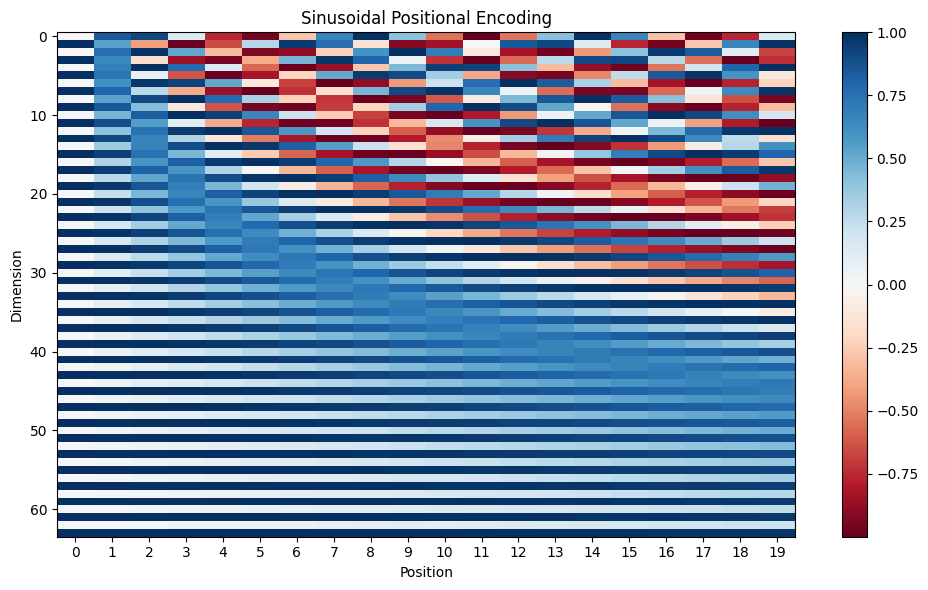

Positional encoding shape: torch.Size([20, 64])


In [16]:
d_model = 64
pe = get_positional_encoding(max_sequence_len, d_model)

plt.figure(figsize=(10, 6))
plt.imshow(pe.T, aspect='auto', cmap='RdBu', origin='upper')
plt.colorbar()
plt.title('Sinusoidal Positional Encoding')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.xticks(range(max_sequence_len))
plt.tight_layout()
plt.show()
print(f'Positional encoding shape: {pe.shape}')

# Implementation of the transformer model

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_k = d_model // 4 
        self.scale = math.sqrt(self.d_k)
    
    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)
        return output, attention_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()
        Q = self.W_Q(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        attn_output, _ = self.attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_O(attn_output)
        return self.dropout(output)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.dropout(self.linear2(F.relu(self.linear1(x))))

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        residual = x
        x = self.norm1(x)
        x = self.self_attention(x, mask)
        x = self.dropout(x)
        x = residual + x
        residual = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = residual + x
        return x

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = get_positional_encoding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.output_layer = nn.Linear(d_model, vocab_size)
    
    def create_causal_mask(self, seq_len):
        mask = torch.tril(torch.ones((seq_len, seq_len))).unsqueeze(0).unsqueeze(0)
        return mask
    
    def forward(self, x, padding_mask=None):
        batch_size, seq_len = x.shape
        token_embeds = self.token_embedding(x) * math.sqrt(self.d_model)
        pos_embeds = self.positional_encoding[:seq_len, :].to(x.device)
        x = token_embeds + pos_embeds
        x = self.dropout(x)
        causal_mask = self.create_causal_mask(seq_len).to(x.device)
        if padding_mask is not None:
            mask = causal_mask & padding_mask.unsqueeze(1).unsqueeze(2)
        else:
            mask = causal_mask
        for decoder_block in self.decoder_blocks:
            x = decoder_block(x, mask)
        x = self.norm(x)
        output = self.output_layer(x)
        return output

vocab_size = 29
max_seq_len = 20
d_model = 64
n_layers = 3
n_heads = 4
d_ff = 256
dropout = 0.1

model = DecoderOnlyTransformer(vocab_size, max_seq_len, d_model, n_layers, n_heads, d_ff, dropout)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Model architecture:\n{model}")


Total parameters: 153,821
Model architecture:
DecoderOnlyTransformer(
  (token_embedding): Embedding(29, 64)
  (dropout): Dropout(p=0.1, inplace=False)
  (decoder_blocks): ModuleList(
    (0-2): 3 x DecoderBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (self_attention): MultiHeadAttention(
        (W_Q): Linear(in_features=64, out_features=64, bias=True)
        (W_K): Linear(in_features=64, out_features=64, bias=True)
        (W_V): Linear(in_features=64, out_features=64, bias=True)
        (W_O): Linear(in_features=64, out_features=64, bias=True)
        (attention): ScaledDotProductAttention()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
   

# Training phase

Epoch 1/3 - Time: 1967.62s - Train Loss: 2.0360 - Val Loss: 1.8712
Epoch 2/3 - Time: 2038.71s - Train Loss: 1.8908 - Val Loss: 1.8039
Epoch 3/3 - Time: 2257.28s - Train Loss: 1.8481 - Val Loss: 1.7673


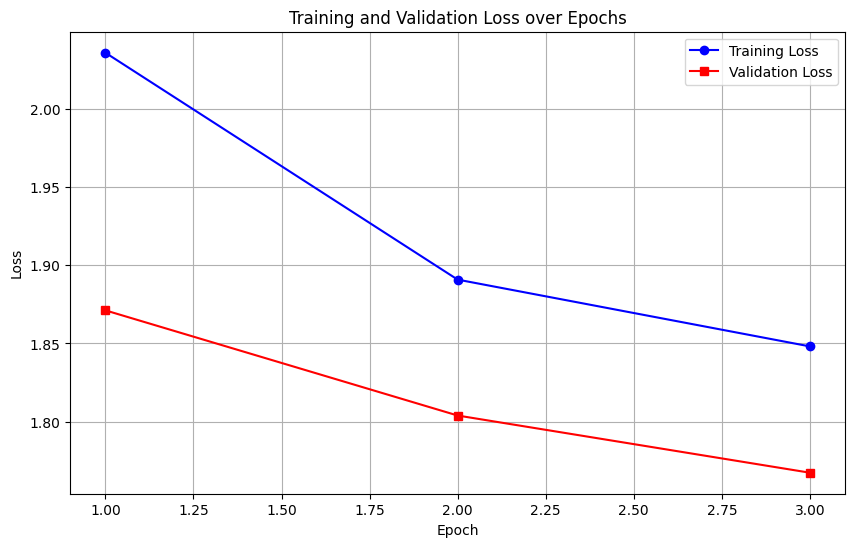


Final Training Loss: 1.8481
Final Validation Loss: 1.7673


In [ ]:
X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)

val_size = int(len(dataset) * 0.1)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

pad_idx = token2index['<PAD>']
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

model = DecoderOnlyTransformer(vocab_size, max_seq_len, d_model, n_layers, n_heads, d_ff, dropout)
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cpu')
model.to(device)

epochs = 3
train_losses = []
val_losses = []

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    total_train_loss = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.view(-1, vocab_size)
        targets = targets.view(-1)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            outputs = outputs.view(-1, vocab_size)
            targets = targets.view(-1)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    end_time = time.time()
    epoch_time = end_time - start_time
    
    print(f'Epoch {epoch+1}/{epochs} - Time: {epoch_time:.2f}s - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_losses, 'b-', label='Training Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, 'r-', label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

print(f'\nFinal Training Loss: {train_losses[-1]:.4f}')
print(f'Final Validation Loss: {val_losses[-1]:.4f}')

# Inference

In [ ]:
index2token = {key:value for key, value in enumerate(vocabulary)}
index2token

{0: '<PAD>',
 1: '<SOS>',
 2: '<EOS>',
 3: 'a',
 4: 'b',
 5: 'c',
 6: 'd',
 7: 'e',
 8: 'f',
 9: 'g',
 10: 'h',
 11: 'i',
 12: 'j',
 13: 'k',
 14: 'l',
 15: 'm',
 16: 'n',
 17: 'o',
 18: 'p',
 19: 'q',
 20: 'r',
 21: 's',
 22: 't',
 23: 'u',
 24: 'v',
 25: 'w',
 26: 'x',
 27: 'y',
 28: 'z'}

In [ ]:
def generate_names(model, start_string, token2index, index2token, max_seq_len, temperature, num_generations=5):
    model.eval()
    sos_idx = token2index['<SOS>']
    eos_idx = token2index['<EOS>']
    pad_idx = token2index['<PAD>']
    
    generated_names = []
    
    with torch.no_grad():
        for _ in range(num_generations):
            start_chars = start_string.lower()
            input_seq = [sos_idx]
            
            for ch in start_chars:
                if ch in token2index:
                    input_seq.append(token2index[ch])
                else:
                    input_seq.append(token2index['a'])
            
            for _ in range(max_seq_len - len(input_seq)):
                input_tensor = torch.tensor([input_seq], dtype=torch.long)
                
                outputs = model(input_tensor)
                
                next_token_logits = outputs[0, -1, :] / temperature
                
                if temperature == 0:
                    next_token = torch.argmax(next_token_logits).item()
                else:
                    probs = F.softmax(next_token_logits, dim=-1)
                    next_token = torch.multinomial(probs, 1).item()
                
                if next_token == eos_idx:
                    break
                
                input_seq.append(next_token)
            
            generated_name = ''.join([index2token[idx] for idx in input_seq[1:] if idx != eos_idx and idx != pad_idx])
            generated_names.append(generated_name)
    
    return generated_names

def format_output(start_string, temperature, names):
    print(f"\n{'='*60}")
    print(f"Input: '{start_string}' | Temperature: {temperature}")
    print(f"{'='*60}")
    for i, name in enumerate(names, 1):
        print(f"{i}. {start_string}{name[len(start_string):] if len(name) > len(start_string) else name}")
    print()

test_inputs = ["c", "li", "mar", "a"]
temperatures = [0, 0.5, 1.0]

for start_input in test_inputs:
    for temp in temperatures:
        generated = generate_names(
            model=model,
            start_string=start_input,
            token2index=token2index,
            index2token=index2token,
            max_seq_len=max_seq_len,
            temperature=temp,
            num_generations=5
        )
        format_output(start_input, temp, generated)


Input: 'c' | Temperature: 0
1. cad
2. cad
3. cad
4. cad
5. cad


Input: 'c' | Temperature: 0.5
1. claudio
2. carrol
3. carmella
4. caroleen
5. carmel


Input: 'c' | Temperature: 1.0
1. chas
2. chanestre
3. cassanton
4. caishonda
5. cloreanzo


Input: 'li' | Temperature: 0
1. lia
2. lia
3. lia
4. lia
5. lia


Input: 'li' | Temperature: 0.5
1. lindsey
2. lillian
3. lindsey
4. lindsey
5. lillian


Input: 'li' | Temperature: 1.0
1. linda
2. lianna
3. linesha
4. lisen
5. lindey


Input: 'mar' | Temperature: 0
1. mara
2. mara
3. mara
4. mara
5. mara


Input: 'mar' | Temperature: 0.5
1. marian
2. marian
3. mariya
4. marisa
5. marian


Input: 'mar' | Temperature: 1.0
1. marcelle
2. marvelle
3. marye
4. marielda
5. mariya


Input: 'a' | Temperature: 0
1. aba
2. aba
3. aba
4. aba
5. aba


Input: 'a' | Temperature: 0.5
1. alonie
2. alexandra
3. alla
4. alexandra
5. ashawn


Input: 'a' | Temperature: 1.0
1. ayonna
2. aulysa
3. adalia
4. almeth
5. aliywah

